В этом задании вам предстоит обучить модель для прогнозирования стоимости недвижимости и создать API для модели с помощью FastAPI.

Вам нужно:
- скачать [данные](https://disk.yandex.ru/d/XDNnTb8JdvYpCA) и обучить модель прогнозирования стоимости недвижимости (модель может быть любой сложности, даже линейная регрессия на двух признаках. Можно переиспользовать модель с прошлого ДЗ) - **1 балл**
- Реализуйте код для получения предсказания обученной моделью - **2 балла**
- Реализуйте получение предсказания моделью через post-запрос по адресу `/predict_post` - **2 балла**
- Реализуйте liveness-пробу (health-check) `health` в виде get-запроса  - **2 балла**
- Запустите API через uvicorn, посетите адрес `http://127.0.0.1:8000/docs` и попробуйте отправить get/post запросы к вашему API через интерфейс Swagger-документации. Результаты выполнения запросов сохраните в виде скриншотов в репозитории - **3 балла**



Часть с написанием кода
---



In [1]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
import pickle
import glob
import os
from google.colab import drive

!pip install xgboost

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
data = glob.glob(os.path.join('/content/drive/My Drive/HW_6', 'realty_data.csv'))
df = pd.concat(map(pd.read_csv, data), ignore_index=True)

display(df.head(3))

,product_name,period,price,postcode,address_name,lat,lon,object_type,total_square,rooms,floor,city,settlement,district,area,description,source
0,"3-комнатная, 137 м²",NaN,63000000,127473.0,"2-й Щемиловский переулок, 5а",55.778894,37.608844,Квартира,137.0,3.0,6.0,Москва,NaN,Тверской район,NaN,Просторная квартира свободной планировки с пан...,ЦИАН
1,"Студия, 16,7 м²",NaN,3250000,108815.0,"Харлампиева, 46",55.551025,37.313054,Квартира,16.7,NaN,1.0,Москва,NaN,Филимонковское поселение,NaN,ВНИМАНИЕ! ОЧЕНЬ ПРИВЛЕКАТЕЛЬНОЕ ПРЕ...,Домклик
2,"3-комнатная, 76 м²",NaN,16004680,NaN,"ЖК Прокшино, 8 к4",55.594802,37.431264,Квартира,76.0,3.0,6.0,Москва,NaN,Сосенское поселение,NaN,"Apт.1684018. 0,01% - гибкая ипотека! Воспользу...",Яндекс.Недвижимость


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98822 entries, 0 to 98821
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_name  98822 non-null  object 
 1   period        0 non-null      float64
 2   price         98822 non-null  int64  
 3   postcode      93675 non-null  float64
 4   address_name  98821 non-null  object 
 5   lat           98822 non-null  float64
 6   lon           98822 non-null  float64
 7   object_type   98822 non-null  object 
 8   total_square  98822 non-null  float64
 9   rooms         94840 non-null  float64
 10  floor         98822 non-null  float64
 11  city          91928 non-null  object 
 12  settlement    6894 non-null   object 
 13  district      75111 non-null  object 
 14  area          19498 non-null  object 
 15  description   98573 non-null  object 
 16  source        98822 non-null  object 
dtypes: float64(7), int64(1), object(9)
memory usage: 12.8+ MB


In [5]:
df.describe()

,period,price,postcode,lat,lon,total_square,rooms,floor
count,0.0,9.882200e+04,93675.000000,98822.000000,98822.000000,98822.000000,94840.000000,98822.000000
mean,NaN,2.512122e+07,124503.585119,55.742691,37.586404,66.092176,2.197427,9.905274
std,NaN,3.607234e+07,11956.742109,0.107044,0.169843,48.816204,1.038628,8.219180
min,NaN,1.900000e+06,101000.000000,55.468426,37.136489,8.000000,1.000000,1.000000
25%,NaN,1.050000e+07,115516.000000,55.673101,37.471611,40.100000,1.000000,4.000000
50%,NaN,1.516713e+07,123154.000000,55.745474,37.569365,56.400000,2.000000,8.000000
75%,NaN,2.500000e+07,140003.000000,55.817697,37.689568,75.700000,3.000000,14.000000
max,NaN,1.155219e+09,143989.000000,56.028824,38.122467,2070.000000,15.000000,66.000000


Удалим категориальные признаки, которые либо пустые, либо можно создать простейшую модель и без

In [6]:
df = df.drop(columns=['product_name', 'period', 'address_name', 'object_type','city', 'settlement', 'district', 'area', 'description', 'source', 'postcode', 'lat', 'lon'])

In [7]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94840 entries, 0 to 98821
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         94840 non-null  int64  
 1   total_square  94840 non-null  float64
 2   rooms         94840 non-null  float64
 3   floor         94840 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 3.6 MB


In [8]:
df.head()

,price,total_square,rooms,floor
0,63000000,137.0,3.0,6.0
2,16004680,76.0,3.0,6.0
3,7841776,24.0,1.0,10.0
4,120000000,126.0,3.0,16.0
5,13300000,74.0,3.0,14.0


Нужно предсказывать цену, поэтому выделим её в качестве целевой переменной и  разделим выборки на train и test

In [9]:
x = df.drop(columns='price')
y = df['price']

Построим модель  XGBRegressor

In [10]:
remodel = XGBRegressor(n_estimators=250, learning_rate=0.05, random_state=25)
remodel.fit(x, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=250, n_jobs=None,
             num_parallel_tree=None, random_state=25, ...)

In [11]:
with open("realty_data.pkl", "wb") as a:
    pickle.dump(remodel, a)

In [12]:
%%writefile predict.py

# @title Inference form {display-mode: "form"}
import pickle

def re_load():
    with open("realty_data.pkl", "rb") as a:
        remodel = pickle.load(a)  # Загружаем модель
    return remodel

def predprice(features):
    remodel = re_load()  # Загружаем модель через re_load
    price = remodel.predict([features])
    return round(price[0], 0)  # округляем до целого числа


Overwriting predict.py


Попробуем вывести предсказания с различными параметрами

In [13]:
from predict import predprice

print('Price',predprice([30, 1, 1]))
print('Price',predprice([50, 3, 6]))
print('Price',predprice([40, 2, 4]))
 # Пример использования

Price 7650764.0
Price 13721776.0
Price 11758317.0


API мудрость
---



Рабочий код
---



In [ ]:
# Импортируем библиотеки и FastApi
!pip install fastapi uvicorn pyngrok
import joblib
import uvicorn
import nest_asyncio

import pandas as pd
from fastapi import FastAPI
from fastapi.responses import JSONResponse
from pydantic import BaseModel
from pyngrok import ngrok

app = FastAPI()
# Загрузим модель
with open("realty_data.pkl", 'rb') as file:
    remodel = joblib.load(file)

# Создадим классы для запроса и ответа
class ModelRequestData(BaseModel):
    total_square: float
    rooms: int
    floor: int

class Result(BaseModel):
    price: int

# Создаем сообщение для того чтобы наше API с нами поздоровалось и сказало что оно живое
@app.get("/")
def read_root():
    return {"message": "Welcome to the Realty Price Prediction API"}

# Создаем тестовый вариант обращения к API
@app.get("/realty")
def realty():
    return JSONResponse(content={"message": "Дорого"}, status_code=555)

# Создаем вариант с предсказанием модели с обращением к API
@app.post("/predict", response_model=Result)
def preprocess_data(data:ModelRequestData):
        input_data = data.dict()
        input_df = pd.DataFrame(input_data, index=[0])
        result = int(remodel.predict(input_df)[0])
        return Result(price=result)
# Подключим ngrok
auth_token = "2oW5aWzJhnlBMvo5NkFlKI6o7fe_5ZXRQzH1eEQibMNyBfmz6"
ngrok.set_auth_token(auth_token)
ngrok_tunnel = ngrok.connect(8000)
print('Public URL:', ngrok_tunnel.public_url)

# Запустим API
nest_asyncio.apply()
uvicorn.run(app, host="0.0.0.0", port=8000)


Public URL: https://e341-34-125-224-147.ngrok-free.app


INFO:     Started server process [51123]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     88.201.202.13:0 - "GET / HTTP/1.1" 200 OK
INFO:     88.201.202.13:0 - "GET /docs HTTP/1.1" 200 OK
INFO:     88.201.202.13:0 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     88.201.202.13:0 - "GET / HTTP/1.1" 200 OK
INFO:     88.201.202.13:0 - "GET /realty HTTP/1.1" 555 
INFO:     88.201.202.13:0 - "POST /predict HTTP/1.1" 200 OK


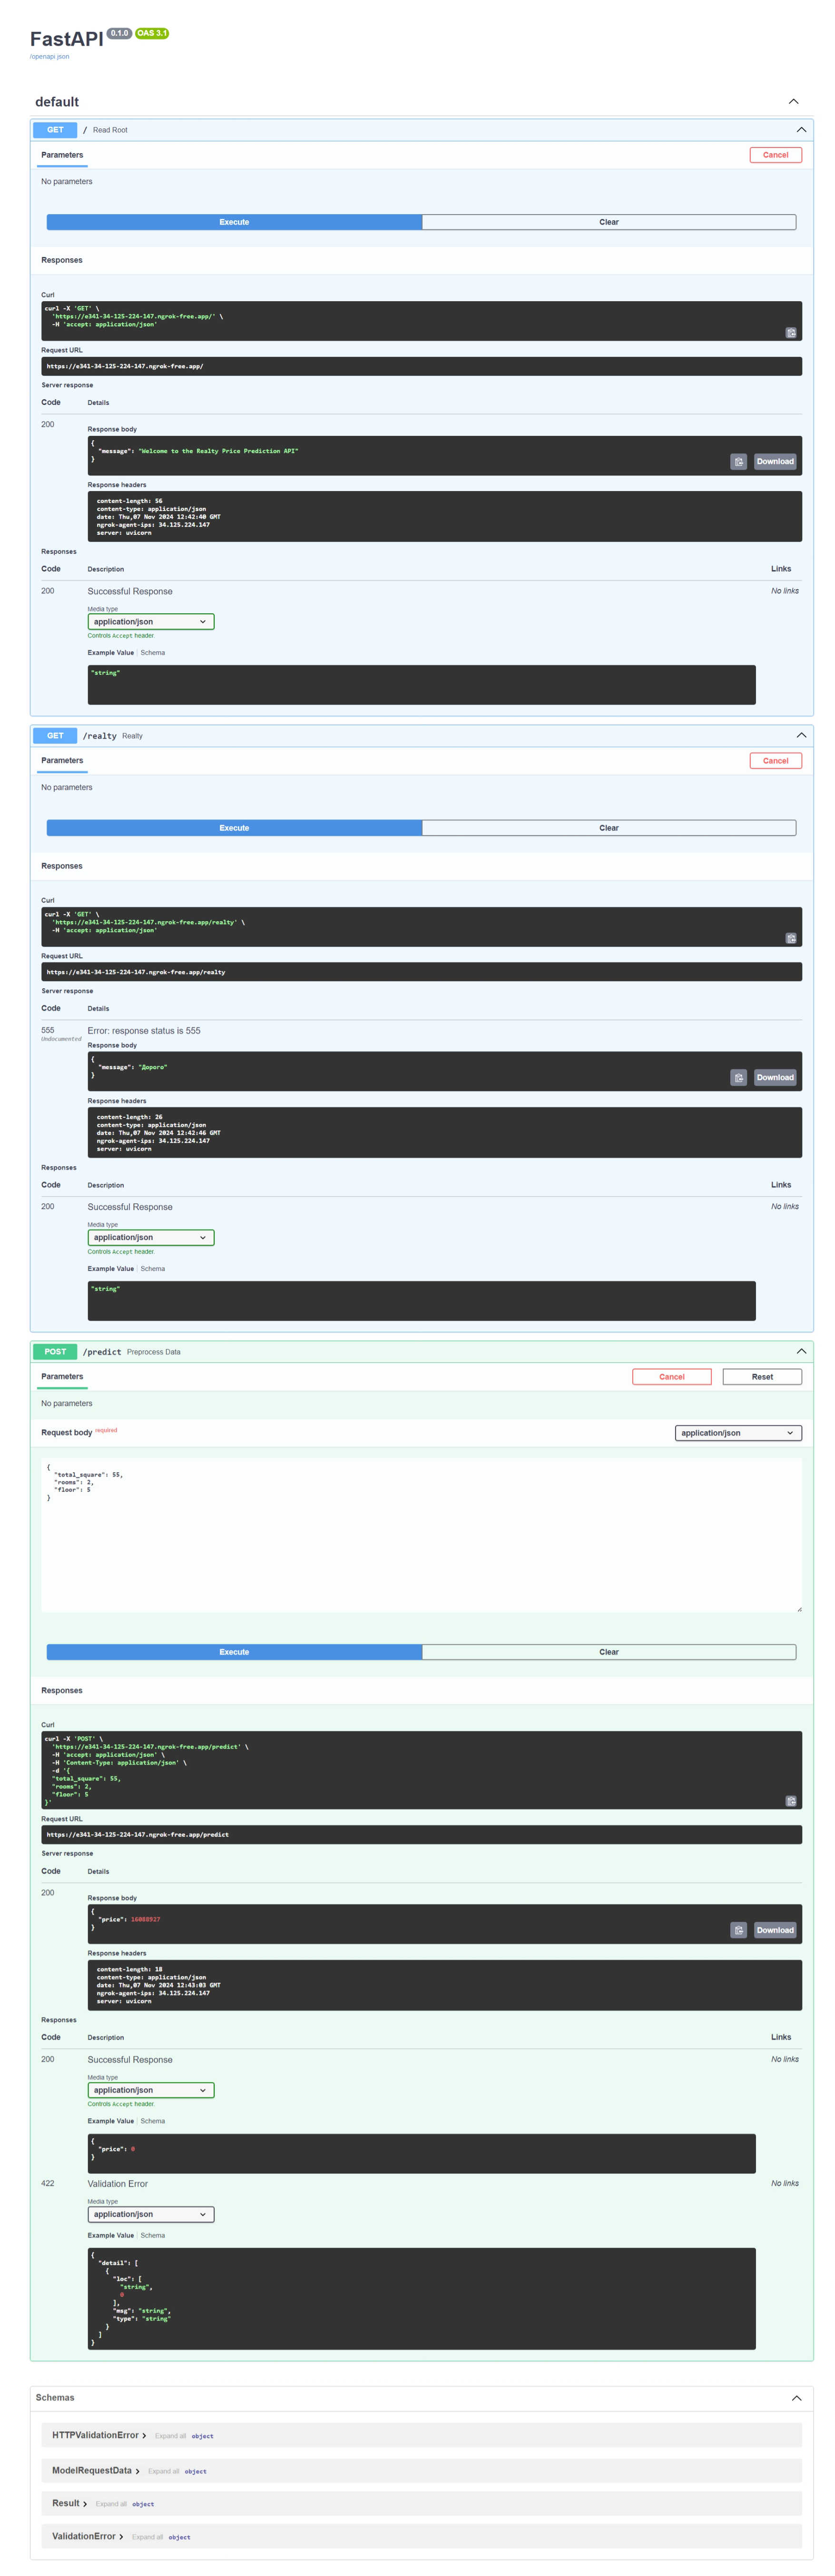